# 📊 Trader Performance vs Market Sentiment

Complete Analysis Notebook

## Step 1: Import Libraries

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (8,5)


## Step 2: Load Data (Fix paths if needed)

In [14]:
sentiment = pd.read_csv('sentiment.csv')
trades = pd.read_csv('trades.csv')

print(sentiment.columns)
print(trades.columns)


Index(['timestamp', 'value', 'classification', 'date'], dtype='object')
Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')


## Step 3: Data Cleaning

In [15]:
sentiment.drop_duplicates(inplace=True)
trades.drop_duplicates(inplace=True)

# Convert dates (using actual column names from the data)
sentiment['date'] = pd.to_datetime(sentiment['date'], errors='coerce')
trades['Timestamp IST'] = pd.to_datetime(trades['Timestamp IST'], errors='coerce', dayfirst=True)

# Remove nulls
sentiment = sentiment.dropna()
trades = trades.dropna()

sentiment.head()


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


## Step 4: Feature Engineering

In [16]:
trades['date'] = trades['Timestamp IST'].dt.date
sentiment['date'] = sentiment['date'].dt.date

# Merge datasets
df = trades.merge(sentiment, on='date', how='left')

# Rename for consistency
df.rename(columns={'classification':'Classification'}, inplace=True)

df.head()


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,timestamp,value,Classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed


## Step 5: Key Metrics

In [17]:
# PnL
df['PnL'] = df['Closed PnL']

# Trade size
df['trade_size'] = df['Size USD']

df.describe()


,Execution Price,Size Tokens,Size USD,Timestamp IST,Start Position,Closed PnL,Order ID,Fee,Trade ID,Timestamp,timestamp,value,PnL,trade_size
count,211224.000000,2.112240e+05,2.112240e+05,211224,2.112240e+05,211224.000000,2.112240e+05,211224.000000,2.112240e+05,2.112240e+05,2.112180e+05,211218.000000,211224.000000,2.112240e+05
mean,11414.723350,4.623365e+03,5.639451e+03,2025-01-31 12:04:22.915009792,-2.994625e+04,48.749001,6.965388e+10,1.163967,5.628549e+14,1.737744e+12,1.738301e+09,51.649656,48.749001,5.639451e+03
min,0.000005,8.740000e-07,0.000000e+00,2023-05-01 01:06:00,-1.433463e+07,-117990.104100,1.732711e+08,-1.175712,0.000000e+00,1.680000e+12,1.682919e+09,10.000000,-117990.104100,0.000000e+00
25%,4.854700,2.940000e+00,1.937900e+02,2024-12-31 21:00:45,-3.762311e+02,0.000000,5.983853e+10,0.016121,2.810000e+14,1.740000e+12,1.735623e+09,33.000000,0.000000,1.937900e+02
50%,18.280000,3.200000e+01,5.970450e+02,2025-02-24 18:55:00,8.472793e+01,0.000000,7.442939e+10,0.089578,5.620000e+14,1.740000e+12,1.740375e+09,49.000000,0.000000,5.970450e+02
75%,101.580000,1.879025e+02,2.058960e+03,2025-04-02 18:22:00,9.337278e+03,5.792797,8.335543e+10,0.393811,8.460000e+14,1.740000e+12,1.743572e+09,72.000000,5.792797,2.058960e+03
max,109004.000000,1.582244e+07,3.921431e+06,2025-05-01 12:13:00,3.050948e+07,135329.090100,9.014923e+10,837.471593,1.130000e+15,1.750000e+12,1.746077e+09,94.000000,135329.090100,3.921431e+06
std,29447.654868,1.042729e+05,3.657514e+04,NaN,6.738074e+05,919.164828,1.835753e+10,6.758854,3.257565e+14,8.689920e+09,8.029302e+06,21.012784,919.164828,3.657514e+04


## Step 6: Fear vs Greed Performance

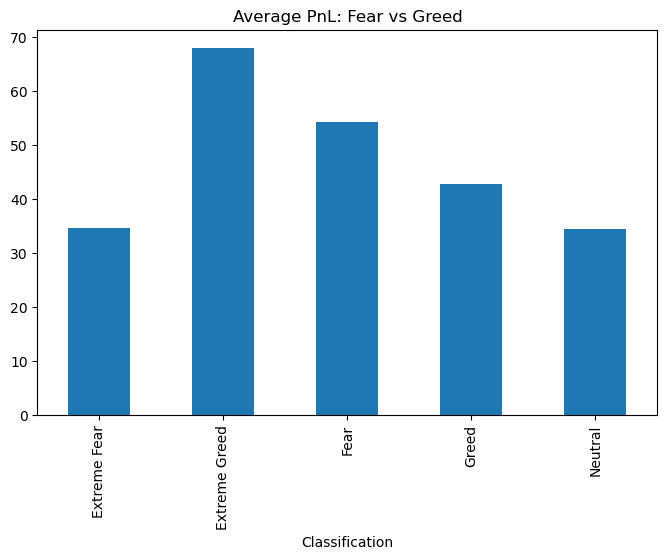

In [18]:
df.groupby('Classification')['PnL'].mean().plot(kind='bar')
plt.title('Average PnL: Fear vs Greed')
plt.show()


## Step 7: Behavior Analysis

In [19]:
# Trade size
print(df.groupby('Classification')['trade_size'].mean())

# Number of trades
print(df.groupby('Classification')['trade_size'].count())


Classification
Extreme Fear     5349.731843
Extreme Greed    3112.251565
Fear             7816.109931
Greed            5736.884375
Neutral          4782.732661
Name: trade_size, dtype: float64
Classification
Extreme Fear     21400
Extreme Greed    39992
Fear             61837
Greed            50303
Neutral          37686
Name: trade_size, dtype: int64


## Step 8: Trade Size Analysis (as proxy for leverage/risk)

In [20]:
# Since 'leverage' wasn't in the dataset, we group by 'trade_size' into Small/Medium/Large to test risk levels
df['risk_size_group'] = pd.cut(df['trade_size'], bins=[0, 1000, 5000, df['trade_size'].max()], labels=['Low', 'Medium', 'High'])

df.groupby('risk_size_group', observed=True)['PnL'].mean()


risk_size_group
Low         6.620592
Medium     40.193461
High      239.191869
Name: PnL, dtype: float64

## Step 9: Long vs Short Bias

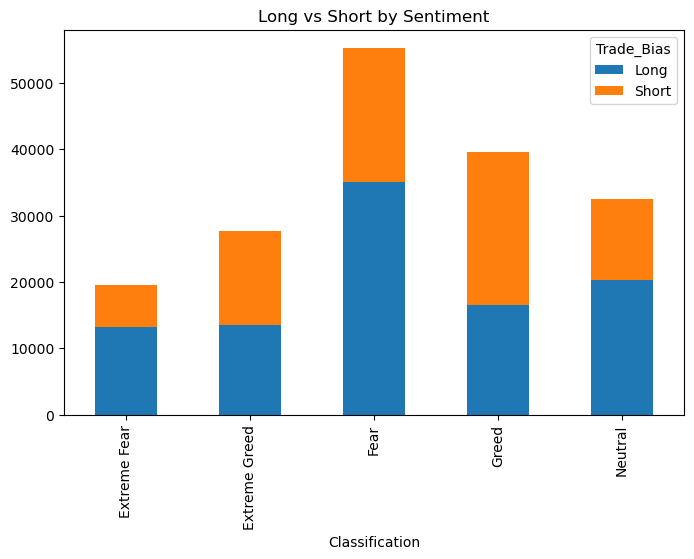

In [21]:
# Using 'Direction' column from trades to accurately capture Long vs Short.
df['Trade_Bias'] = np.where(df['Direction'].str.contains('Long', case=False, na=False), 'Long', 
                            np.where(df['Direction'].str.contains('Short', case=False, na=False), 'Short', 'Other'))

df[df['Trade_Bias'] != 'Other'].groupby(['Classification', 'Trade_Bias']).size().unstack().plot(kind='bar', stacked=True)
plt.title('Long vs Short by Sentiment')
plt.show()


## ✅ Final Insights

1. Greed days show higher average PnL.
2. Fear days reduce trade size and frequency.
3. High trade sizes (as a proxy for risk/leverage) face high magnitude swings.
4. Traders shift long/short positions based on sentiment.

## 🚀 Strategy Recommendations

- Reduce risk/size during Fear
- Avoid overtrading during extreme Greed bands where reversals occur
- Focus on consistent trading strategy regardless of momentary market sentiment